## Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pickle

## Đọc dữ liệu từ file CSV

In [2]:
df = pd.read_csv(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\data\live\sales_dashboard.csv")
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['date'] = df['order_purchase_timestamp'].dt.date

daily_df = df.groupby('date')['payment_value'].sum().reset_index()
daily_df.columns = ['date', 'daily_revenue']
daily_df['date'] = pd.to_datetime(daily_df['date'])


In [3]:
## FEATURE ENGINEERING

In [4]:
daily_df['day_of_week'] = daily_df['date'].dt.dayofweek
daily_df['month'] = daily_df['date'].dt.month
daily_df['day_of_month'] = daily_df['date'].dt.day
daily_df['is_weekend'] = daily_df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Định nghĩa X (Biến độc lập) và y (Biến mục tiêu)
features = ['day_of_week', 'month', 'day_of_month', 'is_weekend']
X = daily_df[features]
y = daily_df['daily_revenue']


In [5]:
## TRAIN TEST SPLIT

In [6]:
test_size = 30
X_train = X.iloc[:-test_size]
y_train = y.iloc[:-test_size]
X_test = X.iloc[-test_size:]
y_test = y.iloc[-test_size:]

print("Kích thước X_train:", X_train.shape)
print("Kích thước X_test:", X_test.shape)



Kích thước X_train: (546, 4)
Kích thước X_test: (30, 4)


In [7]:
## TRAIN MODEL

In [8]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("--- ĐÁNH GIÁ LINEAR REGRESSION ---")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:", r2_score(y_test, y_pred_lr))


--- ĐÁNH GIÁ LINEAR REGRESSION ---
MAE: 12224.902911142259
RMSE: 14796.655258981007
R2: -0.1550088541408463


In [9]:
## VISUALIZE

NameError: name 'y_pred' is not defined

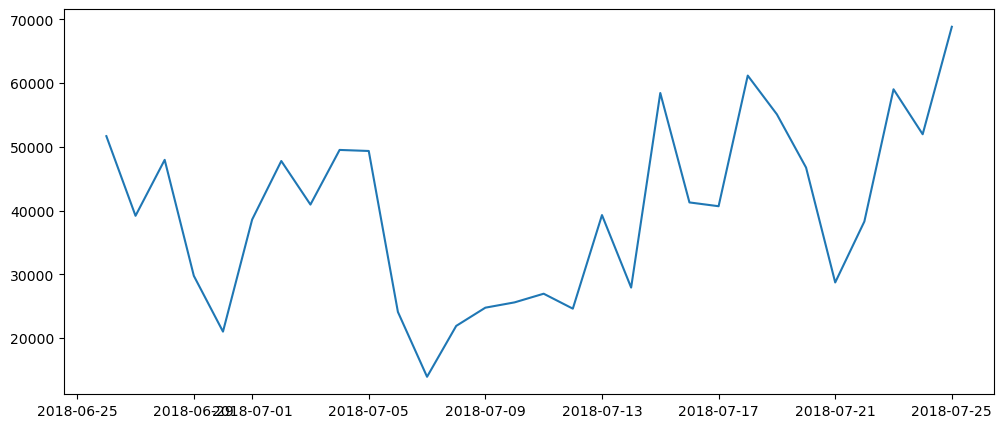

In [10]:
plt.figure(figsize=(12,5))

plt.plot(daily_df['date'].iloc[-30:], y_test.values, label='Actual')
plt.plot(daily_df['date'].iloc[-30:], y_pred, label='Linear')

plt.legend()
plt.title("Linear Regression - Test")
plt.show()

In [ ]:
## TRAIN FULL + SAVE

In [ ]:
lr_final = LinearRegression()
lr_final.fit(X, y)

with open(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models\linear_model.pkl", "wb") as f:
    pickle.dump(lr_final, f)

In [ ]:
## FORECAST 30 NGÀY

In [ ]:
future_days = 30

last_date = daily_df['date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_days)

future_df = pd.DataFrame({'date': future_dates})

future_df['day_of_week'] = future_df['date'].dt.dayofweek
future_df['month'] = future_df['date'].dt.month
future_df['day_of_month'] = future_df['date'].dt.day
future_df['is_weekend'] = future_df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

X_future = future_df[features]

future_df['prediction'] = lr_final.predict(X_future)

plt.figure(figsize=(12,5))
plt.plot(future_df['date'], future_df['prediction'], label='Linear Forecast')
plt.legend()
plt.title("30-day Forecast - Linear")
plt.show()